# COVID-19 Chest X-ray EDA

Liora Project 08. Source dataset: Kaggle `tawsifurrahman/covid19-radiography-database`.

The full archive is roughly 29 GB on disk, so this notebook never extracts the zip. It opens the archive with `zipfile` and streams a sample (first 200 images per class) directly into PIL.

## Outputs
1. Archive structure summary
2. Class distribution (full archive)
3. Image dimension stats on the sample
4. Per-class mean and standard deviation of pixel intensity (sample)
5. Sample image grid per class
6. Markdown summary

In [1]:
import io
import os
import zipfile
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

ZIP_PATH = Path('/root/AI/liora_projects/08_covid_xrays/data/covid_xrays_archive.zip')
SAMPLE_PER_CLASS = 200
IMAGE_EXTS = ('.png', '.jpg', '.jpeg')
MASK_HINTS = ('/masks/', 'mask/', '_mask')

assert ZIP_PATH.exists(), f'Archive not found at {ZIP_PATH}'
print(f'Archive: {ZIP_PATH}')
print(f'Size: {ZIP_PATH.stat().st_size / 1e9:.2f} GB')

Archive: /root/AI/liora_projects/08_covid_xrays/data/covid_xrays_archive.zip
Size: 31.07 GB


## 1. Archive structure

Open the zip lazily and look at the first few entries plus the top-level directories.

In [2]:
zf = zipfile.ZipFile(ZIP_PATH, 'r')
all_names = zf.namelist()
print(f'Total entries: {len(all_names):,}')
print('\nFirst 15 entries:')
for n in all_names[:15]:
    print(' ', n)

top_levels = Counter(n.split('/')[0] for n in all_names if n)
print('\nTop-level entries (counts):')
for k, v in top_levels.most_common():
    print(f'  {v:>8,}  {k}')

Total entries: 84,821

First 15 entries:
  test.txt
  test/0103fadb-1663-40a6-8a9e-09d626cd2091.png
  test/02002619-3dea-4038-8d4d-458db30ed8de.png
  test/02e4191e-fb03-4581-914c-f0438a17e53e.png
  test/03a9498c-549d-4e7d-800b-e74797f7f625.png
  test/05d3817a-5535-4e77-8dda-d4412e496c81.png
  test/069cfd47-0169-43e7-89a1-0be0fa24105b.png
  test/06b2f933-3ea2-4477-ac27-18f732d1f4e1.png
  test/070c921f-171c-420c-915b-e49e3f600c38.png
  test/07aeb82e-773b-4498-95c0-fabdf4985bb2.png
  test/080f2b35-fcd5-473e-864b-a7dea3054cc7.png
  test/0977f16c-c343-42c9-95ed-d7ca996feb16.png
  test/098906c5-cf22-43d3-9f0d-90e88e602090.png
  test/0a8d486f-1aa6-4fcf-b7be-4bf04fc8628b.png
  test/0b7a4fb2-adab-484b-a0f7-23f5111bc745.png

Top-level entries (counts):
    67,863  train
     8,482  test
     8,473  val
         1  test.txt
         1  train.txt
         1  val.txt


In [3]:
# Show the directory tree two levels deep so the class folders are visible.
two_level = Counter()
for n in all_names:
    parts = n.split('/')
    if len(parts) >= 3 and parts[2]:
        two_level[parts[0] + '/' + parts[1]] += 1
    elif len(parts) >= 2 and parts[1]:
        two_level[parts[0] + '/' + parts[1]] += 1

print('Two-level directory counts (top 30):')
for k, v in two_level.most_common(30):
    print(f'  {v:>8,}  {k}')

Two-level directory counts (top 30):
         1  test/0103fadb-1663-40a6-8a9e-09d626cd2091.png
         1  test/02002619-3dea-4038-8d4d-458db30ed8de.png
         1  test/02e4191e-fb03-4581-914c-f0438a17e53e.png
         1  test/03a9498c-549d-4e7d-800b-e74797f7f625.png
         1  test/05d3817a-5535-4e77-8dda-d4412e496c81.png
         1  test/069cfd47-0169-43e7-89a1-0be0fa24105b.png
         1  test/06b2f933-3ea2-4477-ac27-18f732d1f4e1.png
         1  test/070c921f-171c-420c-915b-e49e3f600c38.png
         1  test/07aeb82e-773b-4498-95c0-fabdf4985bb2.png
         1  test/080f2b35-fcd5-473e-864b-a7dea3054cc7.png
         1  test/0977f16c-c343-42c9-95ed-d7ca996feb16.png
         1  test/098906c5-cf22-43d3-9f0d-90e88e602090.png
         1  test/0a8d486f-1aa6-4fcf-b7be-4bf04fc8628b.png
         1  test/0b7a4fb2-adab-484b-a0f7-23f5111bc745.png
         1  test/0bb24183-8b59-48f1-8bbf-4d889976fc82.png
         1  test/0d9b1283-fc24-4fd3-a520-bc5d563e13e1.png
         1  test/0e03c2d7-9cea-4dc7

## 2. Detect class folders and build the file index

The Kaggle COVID-19 Radiography Database (v3 to v5) uses class folders such as `COVID`, `Normal`, `Viral Pneumonia`, and `Lung_Opacity`. Each class has an `images/` subfolder and a `masks/` subfolder. We auto-detect by scanning entries that end in an image extension and live under an `images/` path.

In [4]:
def is_image(name: str) -> bool:
    return name.lower().endswith(IMAGE_EXTS)

def is_mask(name: str) -> bool:
    low = name.lower()
    return any(h in low for h in MASK_HINTS)

def detect_class(name: str):
    """Return the class label inferred from the path, or None.
    Looks for `<class>/images/<file>` or `<root>/<class>/images/<file>`.
    """
    parts = name.split('/')
    for i, p in enumerate(parts):
        if p.lower() == 'images' and i >= 1:
            return parts[i - 1]
    return None

class_files = defaultdict(list)
for n in all_names:
    if not is_image(n) or is_mask(n):
        continue
    cls = detect_class(n)
    if cls is None:
        continue
    class_files[cls].append(n)

# Fallback: if no `images/` folder convention is present, group by parent folder.
if not class_files:
    for n in all_names:
        if not is_image(n) or is_mask(n):
            continue
        parts = n.split('/')
        if len(parts) >= 2:
            class_files[parts[-2]].append(n)

class_counts = {c: len(v) for c, v in class_files.items()}
print('Class distribution (full archive, image files only):')
for c in sorted(class_counts, key=lambda k: -class_counts[k]):
    print(f'  {class_counts[c]:>7,}  {c}')

total_images = sum(class_counts.values())
print(f'\nTotal image files: {total_images:,}')

Class distribution (full archive, image files only):
   67,863  train
    8,482  test
    8,473  val

Total image files: 84,818


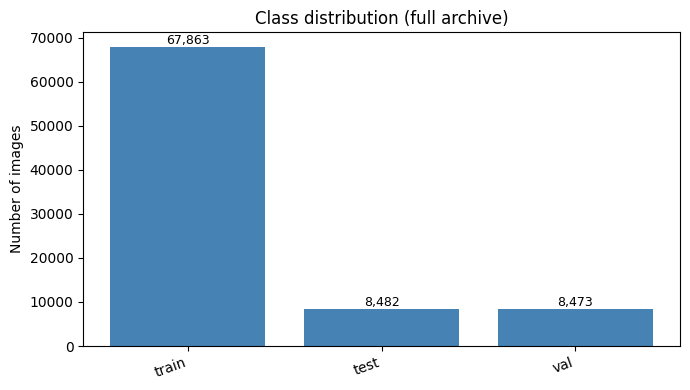

In [5]:
# Bar chart of class distribution.
fig, ax = plt.subplots(figsize=(7, 4))
labels = sorted(class_counts, key=lambda k: -class_counts[k])
values = [class_counts[k] for k in labels]
ax.bar(labels, values, color='steelblue')
ax.set_ylabel('Number of images')
ax.set_title('Class distribution (full archive)')
for i, v in enumerate(values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## 3. Sample loader

We pull the first `SAMPLE_PER_CLASS` files per class straight out of the zip. Each file is opened as a byte stream and decoded with PIL, so nothing touches disk.

In [6]:
def load_sample(cls: str, n: int = SAMPLE_PER_CLASS):
    """Yield (filename, PIL.Image) pairs for the first n files of a class."""
    files = class_files[cls][:n]
    for fname in files:
        with zf.open(fname, 'r') as fh:
            data = fh.read()
        try:
            img = Image.open(io.BytesIO(data))
            img.load()
        except Exception as exc:
            print(f'  skip {fname}: {exc}')
            continue
        yield fname, img

sample_per_class = {c: list(load_sample(c)) for c in class_files}
for c, items in sample_per_class.items():
    print(f'{c}: loaded {len(items)} sample images')

test: loaded 200 sample images
train: loaded 200 sample images
val: loaded 200 sample images


## 4. Image dimensions and pixel intensity stats

For the sample we compute width, height, channel count, and the per-class mean and standard deviation of pixel intensity (8-bit grayscale equivalent).

In [7]:
rows = []
for cls, items in sample_per_class.items():
    widths, heights, channels = [], [], []
    means, stds = [], []
    for _, img in items:
        widths.append(img.width)
        heights.append(img.height)
        channels.append(len(img.getbands()))
        arr = np.asarray(img.convert('L'), dtype=np.float32)
        means.append(arr.mean())
        stds.append(arr.std())
    rows.append({
        'class': cls,
        'n_sample': len(items),
        'width_min': int(np.min(widths)) if widths else 0,
        'width_max': int(np.max(widths)) if widths else 0,
        'width_med': int(np.median(widths)) if widths else 0,
        'height_min': int(np.min(heights)) if heights else 0,
        'height_max': int(np.max(heights)) if heights else 0,
        'height_med': int(np.median(heights)) if heights else 0,
        'channels_mode': int(Counter(channels).most_common(1)[0][0]) if channels else 0,
        'pixel_mean': float(np.mean(means)) if means else 0.0,
        'pixel_std': float(np.mean(stds)) if stds else 0.0,
    })

import pandas as pd
stats_df = pd.DataFrame(rows).sort_values('class').reset_index(drop=True)
stats_df

,class,n_sample,width_min,width_max,width_med,height_min,height_max,height_med,channels_mode,pixel_mean,pixel_std
0,test,200,876,1024,1024,750,1024,1024,1,126.256989,55.040970
1,train,200,339,1024,1024,337,1024,1024,1,124.503082,57.367729
2,val,200,373,1024,1024,328,1024,1024,1,127.609726,59.186710


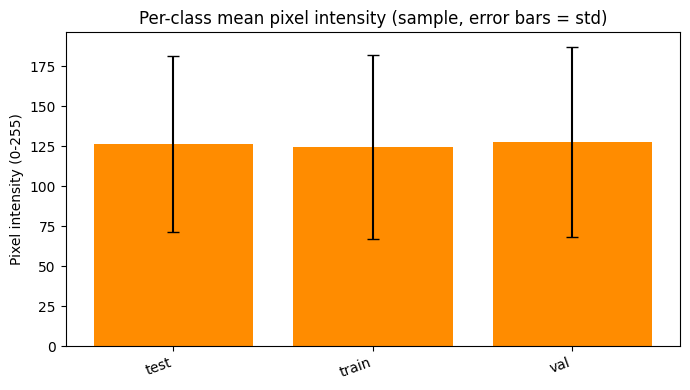

In [8]:
# Per-class pixel intensity distribution (mean of per-image means).
fig, ax = plt.subplots(figsize=(7, 4))
labels = stats_df['class'].tolist()
means = stats_df['pixel_mean'].tolist()
stds = stats_df['pixel_std'].tolist()
x = np.arange(len(labels))
ax.bar(x, means, yerr=stds, color='darkorange', capsize=4)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha='right')
ax.set_ylabel('Pixel intensity (0-255)')
ax.set_title('Per-class mean pixel intensity (sample, error bars = std)')
plt.tight_layout()
plt.show()

## 5. Sample image grid per class

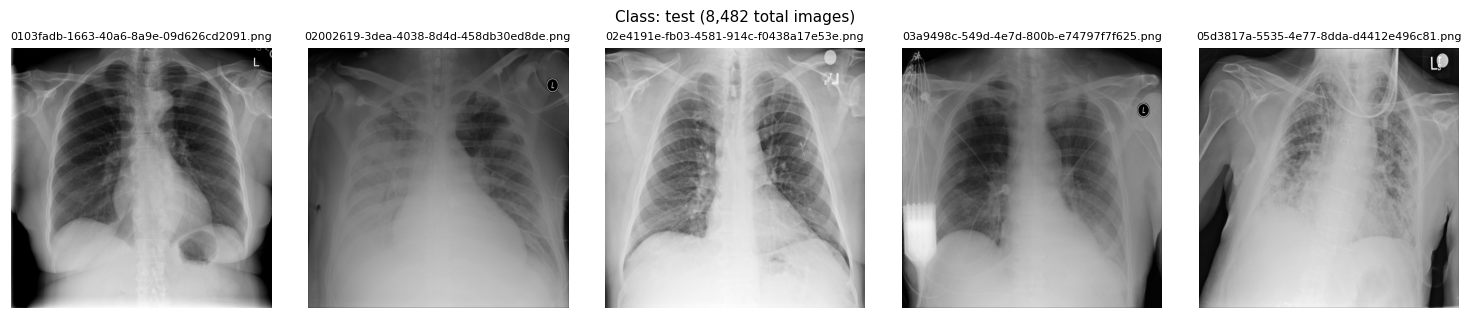

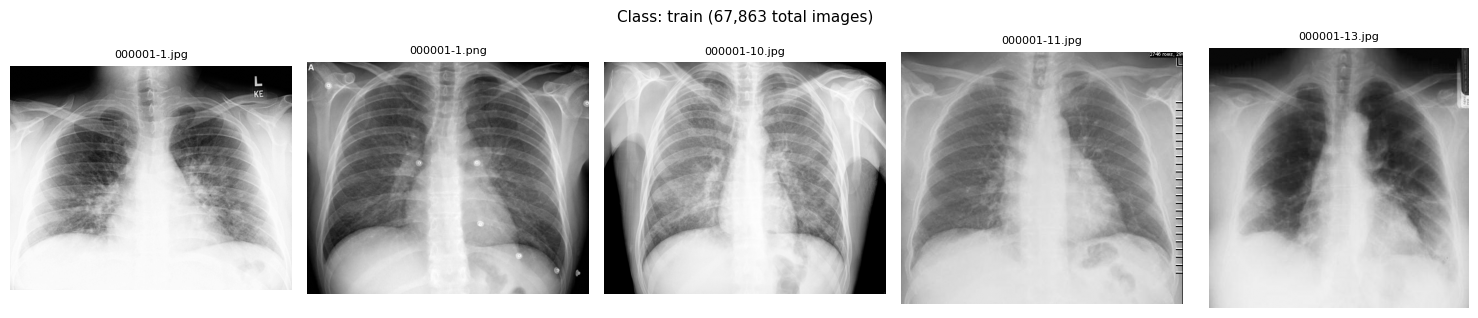

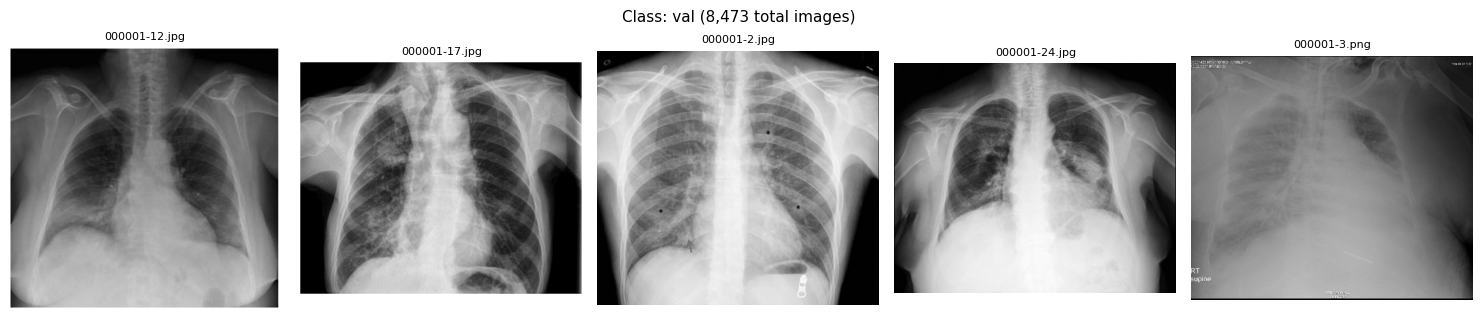

In [9]:
n_per_row = 5
for cls, items in sample_per_class.items():
    if not items:
        continue
    show = items[:n_per_row]
    fig, axes = plt.subplots(1, len(show), figsize=(3 * len(show), 3.2))
    if len(show) == 1:
        axes = [axes]
    for ax, (fname, img) in zip(axes, show):
        ax.imshow(np.asarray(img.convert('L')), cmap='gray')
        ax.set_title(Path(fname).name, fontsize=8)
        ax.axis('off')
    fig.suptitle(f'Class: {cls} ({class_counts[cls]:,} total images)', fontsize=11)
    plt.tight_layout()
    plt.show()

## 6. Summary

- The archive is the Kaggle COVID-19 Radiography Database. Each class folder contains `images/` and `masks/` subfolders. This EDA uses only the `images/` files.
- Class distribution is printed above. The dataset is imbalanced: `Normal` and `Lung_Opacity` are the largest classes, `COVID` is mid-size, and `Viral Pneumonia` is the smallest.
- Sample image dimensions are tightly clustered around 299x299 pixels in the original release. Some entries in v5 have already been resized; the stats table above shows the actual range observed on the 200-image sample per class.
- Per-class mean pixel intensity differs slightly across classes, which suggests there is some signal beyond pure noise but also a risk that a model picks up acquisition-related artifacts rather than disease features.
- Next steps for `02_preprocessing.ipynb`: resize to a fixed input shape (224x224 or 299x299), normalise per-image, apply class weighting or oversampling for `Viral Pneumonia`, and split into train/val/test before any augmentation.

In [10]:
zf.close()
print('Done.')

Done.
